# Processed 5M Dataset Visualization

This notebook inspects the processed CNN input arrays from `data/processed/5M` without loading the full dataset into RAM.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

In [4]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'processed' / '5M' / 'shapes.json').exists():
            return candidate
    raise FileNotFoundError('Could not find data/processed/5M/shapes.json from the current notebook path.')


BASE_DIR = find_repo_root(Path.cwd())
PROCESSED_DIR = BASE_DIR / 'data' / 'processed' / '5M'

FEATURE_NAMES = [
    'close_ret', 'open_ret', 'high_ret', 'low_ret', 'vol_ret',
    'body_ratio', 'upper_wick', 'lower_wick',
    'engulf_bull', 'engulf_bear', 'doji', 'vol_surge',
]
LABEL_NAMES = {0: 'HOLD', 1: 'BUY', 2: 'SELL'}

PROCESSED_DIR

PosixPath('/home/vedvn/ml-quant/data/processed/5M')

In [14]:
with open(PROCESSED_DIR / 'shapes.json', 'r') as f:
    shapes = json.load(f)

X_train = np.memmap(PROCESSED_DIR / 'X_train.npy', dtype=np.float32, mode='r', shape=tuple(shapes['train_shape']))
X_val = np.memmap(PROCESSED_DIR / 'X_val.npy', dtype=np.float32, mode='r', shape=tuple(shapes['val_shape']))
X_test = np.memmap(PROCESSED_DIR / 'X_test.npy', dtype=np.float32, mode='r', shape=tuple(shapes['test_shape']))

y_train = np.memmap(PROCESSED_DIR / 'y_train.npy', dtype=np.int64, mode='r', shape=(shapes['train_shape'][0],))
y_val = np.memmap(PROCESSED_DIR / 'y_val.npy', dtype=np.int64, mode='r', shape=(shapes['val_shape'][0],))
y_test = np.memmap(PROCESSED_DIR / 'y_test.npy', dtype=np.int64, mode='r', shape=(shapes['test_shape'][0],))

datasets = {
    'train': (X_train, y_train),
    'val': (X_val, y_val),
    'test': (X_test, y_test),
}

shape_summary = pd.DataFrame([
    {
        'split': split,
        'X_shape': X.shape,
        'y_shape': y.shape,
        'windows': X.shape[0],
        'lookback_steps': X.shape[1],
        'features': X.shape[2],
    }
    for split, (X, y) in datasets.items()
])
shape_summary

,split,X_shape,y_shape,windows,lookback_steps,features
0,train,"(880265, 60, 12)","(880265,)",880265,60,12
1,val,"(110022, 60, 12)","(110022,)",110022,60,12
2,test,"(110022, 60, 12)","(110022,)",110022,60,12


In [6]:
def label_summary(labels: np.ndarray, split: str) -> pd.DataFrame:
    counts = np.bincount(np.asarray(labels), minlength=3)
    total = counts.sum()
    return pd.DataFrame({
        'split': split,
        'label': [LABEL_NAMES[i] for i in range(3)],
        'class_id': range(3),
        'count': counts,
        'percent': counts / total * 100,
    })


labels_df = pd.concat(
    [label_summary(y, split) for split, (_, y) in datasets.items()],
    ignore_index=True,
)
labels_df

,split,label,class_id,count,percent
0,train,HOLD,0,241554,27.441055
1,train,BUY,1,254482,28.909703
2,train,SELL,2,384229,43.649242
3,val,HOLD,0,30053,27.315446
4,val,BUY,1,30886,28.072567
5,val,SELL,2,49083,44.611987
6,test,HOLD,0,29633,26.933704
7,test,BUY,1,30369,27.602661
8,test,SELL,2,50020,45.463635


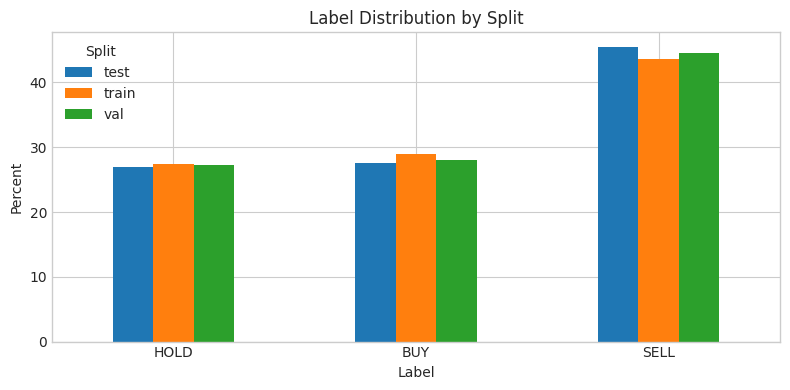

In [7]:
label_pivot = labels_df.pivot(index='label', columns='split', values='percent').loc[['HOLD', 'BUY', 'SELL']]

ax = label_pivot.plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Label Distribution by Split')
ax.set_xlabel('Label')
ax.set_ylabel('Percent')
ax.legend(title='Split')
plt.tight_layout()
plt.show()

In [8]:
SPLIT = 'train'
SAMPLE_WINDOWS = 5_000
RANDOM_SEED = 44

X, y = datasets[SPLIT]
rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(SAMPLE_WINDOWS, X.shape[0])
sample_indices = rng.choice(X.shape[0], size=sample_size, replace=False)

# Shape: sampled windows x 60 lookback steps x 12 engineered features.
sample_windows = np.asarray(X[sample_indices])
sample_flat = sample_windows.reshape(-1, len(FEATURE_NAMES))
sample_df = pd.DataFrame(sample_flat, columns=FEATURE_NAMES)

sample_df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
close_ret,0.000005,0.001875,-0.115774,-0.000633,0.000000,0.000622,0.113083
open_ret,0.000017,0.000971,-0.097191,-0.000023,0.000000,0.000024,0.092242
high_ret,0.000995,0.001613,-0.097191,0.000261,0.000625,0.001251,0.113311
low_ret,-0.001018,0.001617,-0.115774,-0.001317,-0.000671,-0.000295,0.053191
vol_ret,0.168123,0.895081,-1.000000,-0.216323,0.000000,0.226439,10.000000
body_ratio,-0.004327,0.522421,-1.000000,-0.444444,0.000000,0.436855,1.281250
upper_wick,0.264034,0.216833,0.000000,0.083333,0.222222,0.403101,1.000000
lower_wick,0.286944,0.223047,-0.281250,0.102564,0.250000,0.435897,1.000000
engulf_bull,0.032457,0.177210,0.000000,0.000000,0.000000,0.000000,1.000000
engulf_bear,0.030760,0.172667,0.000000,0.000000,0.000000,0.000000,1.000000


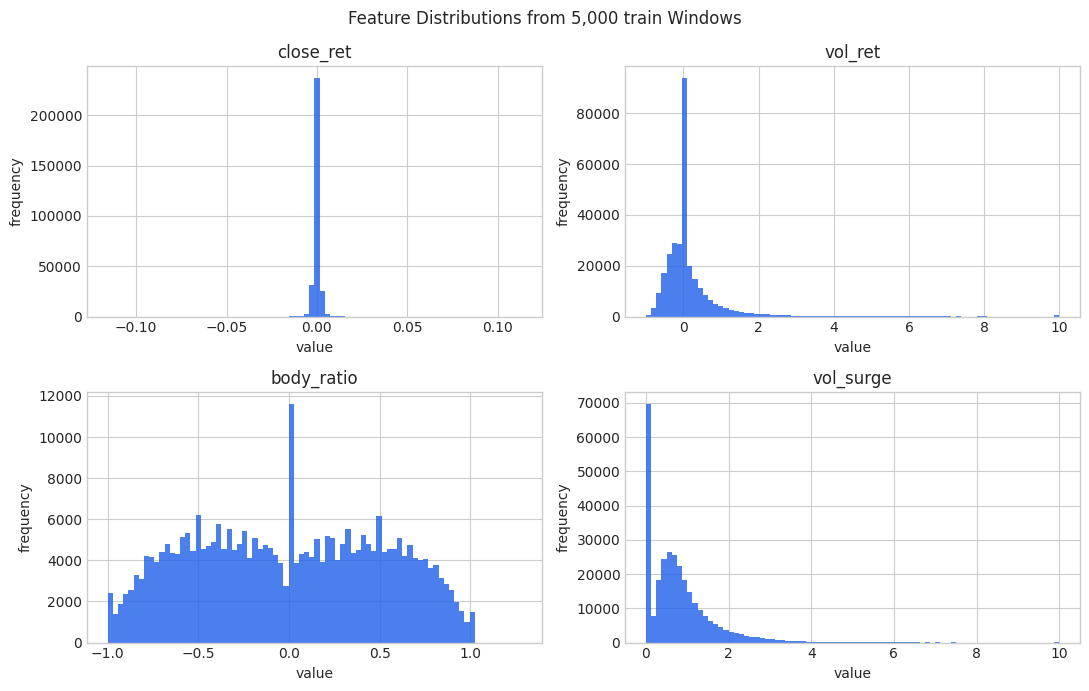

In [9]:
FEATURES_TO_PLOT = ['close_ret', 'vol_ret', 'body_ratio', 'vol_surge']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feature in zip(axes.ravel(), FEATURES_TO_PLOT):
    ax.hist(sample_df[feature], bins=80, color='#2563eb', alpha=0.82)
    ax.set_title(feature)
    ax.set_xlabel('value')
    ax.set_ylabel('frequency')

plt.suptitle(f'Feature Distributions from {sample_size:,} {SPLIT} Windows')
plt.tight_layout()
plt.show()

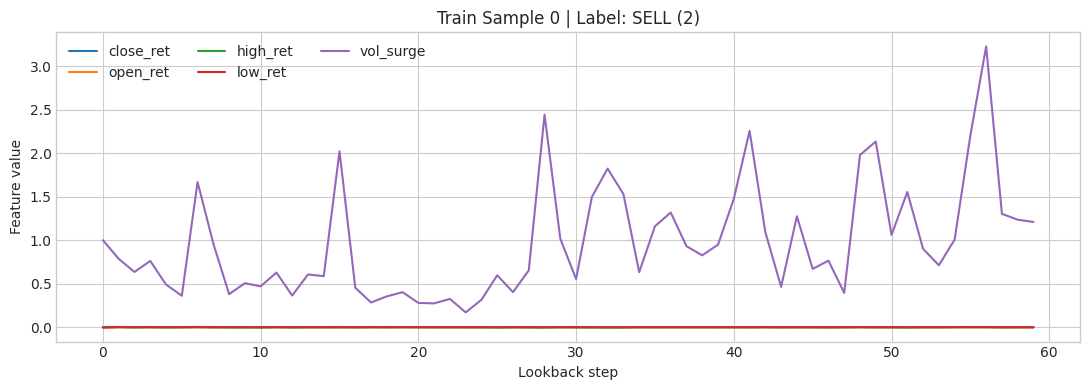

(60, 12)

In [10]:
SAMPLE_INDEX = 0
WINDOW_FEATURES = ['close_ret', 'open_ret', 'high_ret', 'low_ret', 'vol_surge']

window = np.asarray(X_train[SAMPLE_INDEX])
label = int(y_train[SAMPLE_INDEX])
steps = np.arange(window.shape[0])

fig, ax = plt.subplots(figsize=(11, 4))
for feature in WINDOW_FEATURES:
    feature_idx = FEATURE_NAMES.index(feature)
    ax.plot(steps, window[:, feature_idx], label=feature)

ax.set_title(f'Train Sample {SAMPLE_INDEX} | Label: {LABEL_NAMES[label]} ({label})')
ax.set_xlabel('Lookback step')
ax.set_ylabel('Feature value')
ax.legend(loc='upper left', ncols=3)
plt.tight_layout()
plt.show()

window.shape

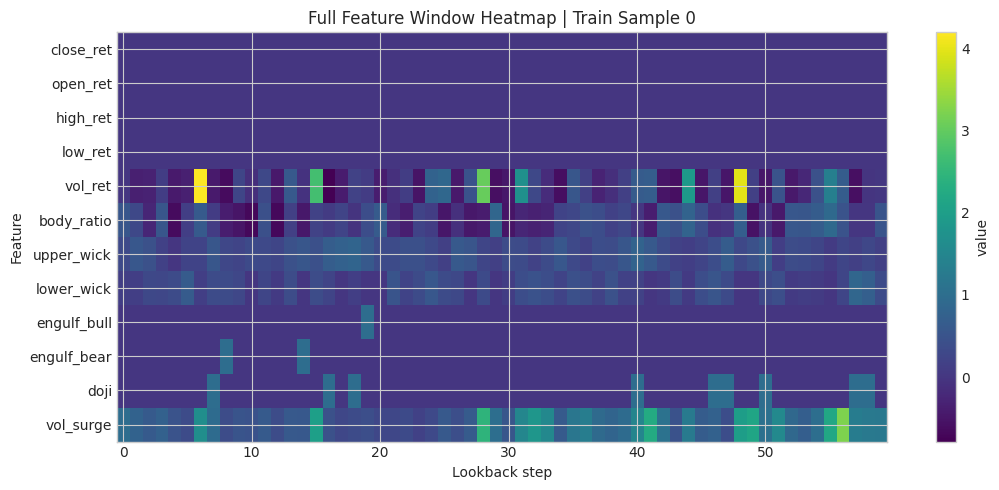

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(window.T, aspect='auto', cmap='viridis', interpolation='nearest')

ax.set_title(f'Full Feature Window Heatmap | Train Sample {SAMPLE_INDEX}')
ax.set_xlabel('Lookback step')
ax.set_ylabel('Feature')
ax.set_yticks(np.arange(len(FEATURE_NAMES)))
ax.set_yticklabels(FEATURE_NAMES)
fig.colorbar(im, ax=ax, label='value')
plt.tight_layout()
plt.show()